In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Load the plot data back

In [2]:
top_n = [ 1, 49,  7,  0, 71]              

selet_cluster = '1' # need to be a str, that's like 'number'

dist_data = np.load(f"fig/cluster_{selet_cluster}_distance_data.npz", allow_pickle=True)

all_dists = dist_data["all_dists"]     # list of arrays (ragged, so allow_pickle=True was needed)
targets = dist_data["targets"]         # red line targets


ang_data = np.load(f"fig/cluster_{selet_cluster}_angles_data.npz", allow_pickle=True)

omega_input = ang_data["omega_input"]                  # shape (1, n_frames, 24)
residues_to_plot = ang_data["residues_to_plot"].tolist()  # convert np.array back to Python list
angles_to_plot = ang_data["angles_to_plot"].tolist()


## Load the fig parameter

In [3]:
data = np.load("fig/labels_cache.npz", allow_pickle=True)

labels_raw = data["labels_raw"]
labels_human = data["labels_human"]
targets = data["targets"]

# Choose depending on flag
human_interpretable_label = True  # <== flip this to False if you want raw

if human_interpretable_label:
    labels = labels_human
else:
    labels = labels_raw

labels

array(['7α11-8NH1', '7α11-8NH1', '7α11-8NH1', '7α11-8NH1', '6α11-8NH1',
       '6α11-8NH1', '6α11-8NH1', '6α11-8NH1', '3α11-8NH1', '3α11-8NH1',
       '3α11-8NH1', '3α11-8NH1', '7α11-7α2', '7α11-7α2', '5α11-5α2',
       '5α11-5α2', '5β3-5α11', '5β3-5α11', '5β3-5α11', '5β3-5α11',
       '5β3-5α11', '5β3-5α11', '4α11-4α2', '4α11-4α2', '3α11-3α2',
       '3α11-3α2', '2α11-2α2', '2α11-2α2', '1α11-1α2', '1α11-1α2',
       '4α11-3α11', '4α11-3α11', '4α11-3α11', '4α11-3α11', '2β3-1α11',
       '2β3-1α11', '2β3-1α11', '2β3-1α11', '2β3-1α11', '2β3-1α11',
       '1α11-2α2', '1α11-2α2', '6β3-5α11', '6β3-5α11', '6β3-5α11',
       '6β3-5α11', '6β3-5α11', '6β3-5α11', '5α11-6α2', '5α11-6α2',
       '7α11-6α11', '7α11-6α11', '7α11-6α11', '7α11-6α11', '2β3-2α11',
       '2β3-2α11', '2β3-2α11', '2β3-2α11', '2β3-2α11', '2β3-2α11',
       '5α11-4α11', '5α11-4α11', '5α11-4α11', '5α11-4α11', '3β3-3α11',
       '3β3-3α11', '3β3-3α11', '3β3-3α11', '3β3-3α11', '3β3-3α11',
       '4β3-4α11', '4β3-4α11', '4β3-4α

In [4]:
def plot_dihedral_quadruplets(
    omega_all,
    residues_to_plot,
    states=range(16),
    use_latex=True,
    angles_to_plot=None, 
    title = None
):
    """
    Plot selected dihedral angle pairs for each residue in each state.

    Parameters:
    -----------
    omega_all : np.ndarray
        Shape (n_states, n_frames, n_dihedrals)
    residues_to_plot : list of int
        Starting indices of each residue block (omega, phi, psi, chi1)
    states : list
        Indices of states to plot
    use_latex : bool
        Use LaTeX formatting for labels
    angles_to_plot : list of str
        Angle pairs to plot. Options:
            'omega_phi', 'omega_psi', 'phi_psi',
            'omega_chi1', 'phi_chi1', 'psi_chi1'
    """
    if angles_to_plot is None:
        angles_to_plot = ["omega_phi", "omega_psi", "phi_psi", "omega_chi1", "phi_chi1", "psi_chi1"]

    scatter_kws = dict(s=2, color='black', alpha=0.3)

    # Axis labels
    if use_latex:
        labels = {
            'phi': r'$\phi$',
            'psi': r'$\psi$',
            'omega': r'$\omega$',
            'chi1': r'$\chi_1$'
        }
    else:
        labels = {
            'phi': 'Phi',
            'psi': 'Psi',
            'omega': 'Omega',
            'chi1': 'Chi1'
        }

    def format_ax(ax, xlabel, ylabel):
        """Set axis limits and ticks based on dihedral type."""
        if labels['phi'] in xlabel:
            ax.set_xlim(-180, 180)
            ax.set_xticks(np.arange(-180, 181, 180))
        else:
            ax.set_xlim(-90, 270)
            ax.set_xticks(np.arange(-90, 271, 180))

        if labels['phi'] in ylabel:
            ax.set_ylim(-180, 180)
            ax.set_yticks(np.arange(-180, 181, 180))
        else:
            ax.set_ylim(-90, 270)
            ax.set_yticks(np.arange(-90, 271, 180))

        ax.set_xlabel(xlabel, labelpad=4)
        ax.set_ylabel(ylabel, labelpad=4)

    # Mapping from angle pair name to (x, y) keys and title suffix
    angle_plot_map = {
        'omega_phi':   ('phi',   'omega'),
        'omega_psi':   ('psi',   'omega'),
        'phi_psi':     ('psi',   'phi'),
        'omega_chi1':  ('chi1',  'omega'),
        'phi_chi1':    ('chi1',  'phi'),
        'psi_chi1':    ('chi1',  'psi'),
    }

    for state_idx in states:
        num_residues = len(residues_to_plot)
        num_pairs = len(angles_to_plot)
        nrows = num_residues
        ncols = num_pairs

        fig, axes = plt.subplots(nrows, ncols, figsize=(1.5 * ncols, 0.7 * nrows), sharex='col')
        axes = np.atleast_2d(axes)

        fig.suptitle(title if title is not None else "Dihedral Plot", fontsize=10)

        for row_idx, residue in enumerate(residues_to_plot):
            omega = omega_all[state_idx, :, residue]
            phi   = omega_all[state_idx, :, residue + 1]
            psi   = omega_all[state_idx, :, residue + 2]
            chi1  = omega_all[state_idx, :, residue + 3]

            angle_data = {
                'omega': omega,
                'phi':   phi,
                'psi':   psi,
                'chi1':  chi1,
            }

            for col_idx, angle_pair in enumerate(angles_to_plot):
                x_key, y_key = angle_plot_map[angle_pair]
                x = angle_data[x_key]
                y = angle_data[y_key]
                ax = axes[row_idx, col_idx]
                ax.scatter(x, y, **scatter_kws)
                format_ax(ax, labels[x_key], labels[y_key])

                if row_idx == 0:
                    ax.set_title(f'{labels[y_key]} vs {labels[x_key]}')
                if col_idx == 0:
                    ax.set_ylabel(f'Res {residue//4}\n{labels[y_key]}')

        #fig.tight_layout()
        fig.subplots_adjust(wspace=0.5)  # adds horizontal space between columns
        plt.show()



## Distance Plot

In [5]:
all_dists.shape

(90, 10)

/var/folders/d8/y2dvs1ln1gjcwccrkvtffr240000gn/T/ipykernel_11666/3983390074.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(all_dists.T, vert=True, patch_artist=True, labels=labels)


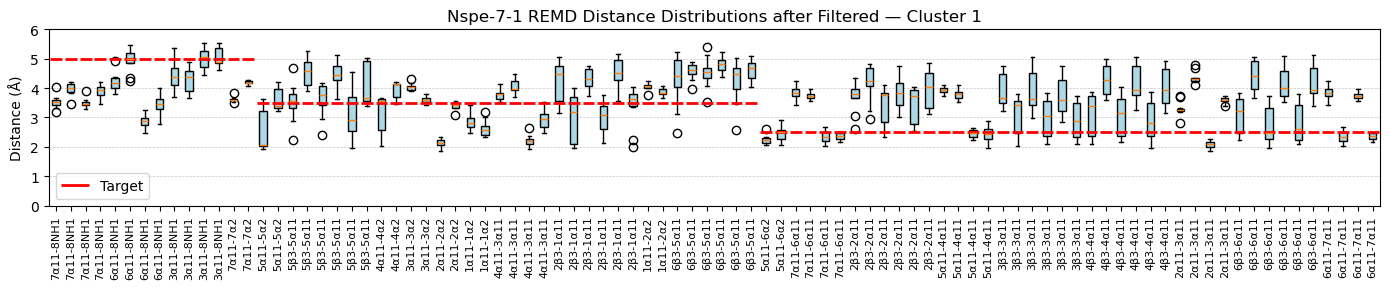

In [6]:
plt.figure(figsize=(14, 3))  # wider horizontally

# Vertical boxplot
bp = plt.boxplot(all_dists.T, vert=True, patch_artist=True, labels=labels)

# Custom styling for boxes
for box in bp['boxes']:
    box.set(facecolor='lightblue')

# Add red target lines (horizontal now)
for xi, ti in enumerate(targets, start=1):  # x starts at 1 in vertical
    plt.hlines(ti, xi - 0.4, xi + 0.4, colors='red', linestyles='-', linewidth=2, label='Target' if xi == 1 else "")

plt.xticks(fontsize=8, rotation=90)
plt.ylabel("Distance (Å)")
plt.title(f"Nspe-7-1 REMD Distance Distributions after Filtered — Cluster {selet_cluster}")
plt.ylim(0, 6)
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.legend()
plt.savefig("fig/Nspe-7-1_REMD_Distance_Distributions_after_Filtered_Cluster_{cluster_label}.png", dpi=300)
plt.show()

## Angle Plot

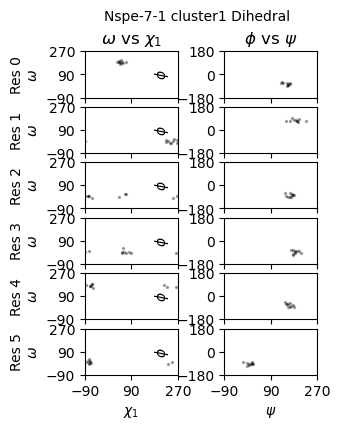

In [7]:
angles_to_plot = ["omega_chi1", "phi_psi"]  # customize as needed


plot_dihedral_quadruplets(
    omega_all=omega_input,
    residues_to_plot=residues_to_plot,
    states=[0],  # Only 1 cluster at a time
    use_latex=True,
    angles_to_plot=angles_to_plot,
    title = f'Nspe-7-1 cluster{selet_cluster} Dihedral'
)